In [1]:
import tensorflow as tf
import keras
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split,KFold
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import time

In [2]:
plt.rcParams['font.sans-serif'] = ['Simhei']   #用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] =  False    #用来正常显示负号

import os
import time
pd.set_option('display.max_columns', 999)    #设置数据展示的最大列数和最大行数
pd.set_option('display.max_rows', 500)

In [3]:
df= pd.read_csv('data-14-01_datawash_all.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77912 entries, 0 to 77911
Columns: 312 entries, COPAY_PCT to PROV_LEVEL_非医保
dtypes: float64(8), int64(304)
memory usage: 185.5 MB


In [5]:
df.describe()


,COPAY_PCT,CWF_AMT_DAY,INVOICE_CNT,POLICY_CNT,ORG_PRES_AMT_VALUE,APP_AMT,REJECTED_AMT,SUB_AMT,CL_SOCIAL_PAY_AMT,CL_THIRD_PARTY_PAY_AMT,CL_OWNER_PAY_AMT,CL_SELF_CAT_PAY_AMT,FRAUD,R530,P8,W010,W057,W056,P18,W220,W180,DX,R899,BD,W190,W360,W080,W340,P19,M033,P16,M130,W020,M110,W620,R140,P10,R897,M143,CF,M109,M060,R682,M004,R610,W400,M107,M114,M121,M028,M155,W120,M119,W560,P3,W100,DT,W055,W280,R894,W420,P12,M113,M149,W410,W230,W450,M118,DO,W310,M029,P17,M009,T420,M144,R560,R040,P5,AE,W040,R180,W210,P2,R260,IB,R520,M120,R658,R030,R130,P20,T460,T310,M111,LG,R060,R680,M117,R010,R625,T450,W260,R540,T250,R100,M002,T190,R170,R270,LB,W270,R896,R542,R605,W200,W390,M133,P9,W380,W070,M116,R860,P11,W090,W290,W105,W250,P4,R600,T180,W600,P1,M101,W050,P15,W590,R898,M123,BEN_TYPE_DB-IP,BEN_TYPE_DB-OP,BEN_TYPE_DT,BEN_TYPE_GG-IP,BEN_TYPE_GG-OP,BEN_TYPE_IP,BEN_TYPE_IPCASB,BEN_TYPE_JW-OP,BEN_TYPE_MA,BEN_TYPE_MAIP,BEN_TYPE_MAOP,BEN_TYPE_MDB,BEN_TYPE_MEMR,BEN_TYPE_MT,BEN_TYPE_OP,BEN_TYPE_PA,BEN_TYPE_VS,BEN_TYPE_YW-IP,BEN_TYPE_YW-OP,MBR_TYPE_Applicant,MBR_TYPE_Child,MBR_TYPE_Parents,MBR_TYPE_Spouse,BEN_HEAD_100PF,BEN_HEAD_100PF-JCF,BEN_HEAD_100PF-YPF,BEN_HEAD_3MM,BEN_HEAD_ACUP,BEN_HEAD_BTAT,BEN_HEAD_CASB,BEN_HEAD_CASB-ZJ,BEN_HEAD_CC-CLF,BEN_HEAD_CC-GHF,BEN_HEAD_CC-JCF,BEN_HEAD_CC-MZSS,BEN_HEAD_CC-YPF,BEN_HEAD_CC-ZLF,BEN_HEAD_CGP,BEN_HEAD_CR,BEN_HEAD_CWF,BEN_HEAD_CYDY,BEN_HEAD_ER,BEN_HEAD_EXC,BEN_HEAD_EXLS,BEN_HEAD_EXZL,BEN_HEAD_F-CJF,BEN_HEAD_F-CLF,BEN_HEAD_F-CWF,BEN_HEAD_F-GHF,BEN_HEAD_F-HERB,BEN_HEAD_F-JCF,BEN_HEAD_F-MZSS,BEN_HEAD_F-PHYS,BEN_HEAD_F-YPF,BEN_HEAD_F-ZFJC,BEN_HEAD_F-ZFYP,BEN_HEAD_F-ZLF,BEN_HEAD_F-ZYF,BEN_HEAD_F-ZYJC,BEN_HEAD_FLZFYP,BEN_HEAD_GHF,BEN_HEAD_HERB,BEN_HEAD_HVIS,BEN_HEAD_INFB,BEN_HEAD_JCF,BEN_HEAD_JSB-YPF,BEN_HEAD_JSB-ZLF,BEN_HEAD_JW-GHF,BEN_HEAD_JW-YPF,BEN_HEAD_JZF-JCF,BEN_HEAD_JZF-YPF,BEN_HEAD_JZF-ZFYP,BEN_HEAD_JZS-GHF,BEN_HEAD_JZS-JCF,BEN_HEAD_JZS-YPF,BEN_HEAD_LAB,BEN_HEAD_LAMB,BEN_HEAD_LC,BEN_HEAD_LENS,BEN_HEAD_MA/COP,BEN_HEAD_MA/NBC,BEN_HEAD_MF,BEN_HEAD_MISC,BEN_HEAD_MND,BEN_HEAD_MSD,BEN_HEAD_MT-CLF,BEN_HEAD_MT-GHF,BEN_HEAD_MT-JCF,BEN_HEAD_MT-MZSS,BEN_HEAD_MT-YPF,BEN_HEAD_MT-ZLF,BEN_HEAD_MTR,BEN_HEAD_MZGKYC,BEN_HEAD_MZY,BEN_HEAD_NBC,BEN_HEAD_NF,BEN_HEAD_NF-JCF,BEN_HEAD_NF-YPF,BEN_HEAD_NS-GHF,BEN_HEAD_NS-JCF,BEN_HEAD_NS-YPF,BEN_HEAD_NS-ZFYP,BEN_HEAD_NS-ZLF,BEN_HEAD_O1K-MZY,BEN_HEAD_O1K-ZFYP,BEN_HEAD_O1K-ZYF,BEN_HEAD_OE,BEN_HEAD_OPR,BEN_HEAD_OV,BEN_HEAD_PHYS,BEN_HEAD_PS,BEN_HEAD_RB,BEN_HEAD_RH-CLF,BEN_HEAD_RH-GHF,BEN_HEAD_RH-JCF,BEN_HEAD_RH-OV,BEN_HEAD_RH-PS,BEN_HEAD_RH-YPF,BEN_HEAD_RH-ZLF,BEN_HEAD_RX,BEN_HEAD_S-CJF,BEN_HEAD_S-CLF,BEN_HEAD_S-CWF,BEN_HEAD_S-FMF,BEN_HEAD_S-GHF,BEN_HEAD_S-JCF,BEN_HEAD_S-MT,BEN_HEAD_S-MZSS,BEN_HEAD_S-OV,BEN_HEAD_S-PS,BEN_HEAD_S-YPF,BEN_HEAD_S-ZFYP,BEN_HEAD_S-ZLF,BEN_HEAD_S-ZYF,BEN_HEAD_S-ZYJC,BEN_HEAD_SC1,BEN_HEAD_SH1,BEN_HEAD_SPFRM,BEN_HEAD_SPLEN,BEN_HEAD_THER,BEN_HEAD_TRTC,BEN_HEAD_TW,BEN_HEAD_TX-GHF,BEN_HEAD_TX-JCF,BEN_HEAD_TX-MZSS,BEN_HEAD_TX-YPF,BEN_HEAD_TX-ZLF,BEN_HEAD_WSS-YPF,BEN_HEAD_YJ-GHF,BEN_HEAD_YJ-JCF,BEN_HEAD_YJ-MZSS,BEN_HEAD_YJ-YPF,BEN_HEAD_YJ-ZLF,BEN_HEAD_YPF,BEN_HEAD_YW-JCF,BEN_HEAD_YW-YPF,BEN_HEAD_YW-ZLF,BEN_HEAD_YWS-ZYF,BEN_HEAD_ZLF,BEN_HEAD_ZY-CWF,BEN_HEAD_ZY-CYDY,BEN_HEAD_ZY-LC,BEN_HEAD_ZY-YPF,BEN_HEAD_ZY-ZFYP,BEN_HEAD_ZYF,PROV_LEVEL_一级,PROV_LEVEL_三级,PROV_LEVEL_二级,PROV_LEVEL_医保,PROV_LEVEL_卫生所,PROV_LEVEL_未知,PROV_LEVEL_未评级,PROV_LEVEL_特需,PROV_LEVEL_非医保
count,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,75954.000000,75954.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.000000,77912.00

In [6]:
# APP_AMT PAY_AMT REJECTED_AMT
df.drop(columns=['APP_AMT', 'REJECTED_AMT'],inplace= True)


In [7]:
# FRAUD 列为目标变量
df['FRAUD'].value_counts()
# 0:正常 1:欺诈

FRAUD
0    65743
1    12169
Name: count, dtype: int64

In [8]:
# 分离特征和标签
X = df.drop(columns=['FRAUD'])
y = df['FRAUD']
# 训练集和测试集划分
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77912 entries, 0 to 77911
Columns: 309 entries, COPAY_PCT to PROV_LEVEL_非医保
dtypes: float64(6), int64(303)
memory usage: 183.7 MB


In [10]:
# random forest
from sklearn.ensemble import RandomForestClassifier
import pickle
#导入model_rfc.pkl
with open('model_rfc.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

c:\Users\12132\Desktop\Project_hemeow\pyvenv\TFvenv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\12132\Desktop\Project_hemeow\pyvenv\TFvenv\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [84]:
# svm
from sklearn.svm import SVC
# 创建SVM模型
model = SVC(kernel='linear', C=1.0, random_state=42)
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))




Confusion Matrix:
[[7592    7]
 [  45  649]]
Classification Report:
              precision    recall  f1-score   support

           0   0.994108  0.999079  0.996587      7599
           1   0.989329  0.935159  0.961481       694

    accuracy                       0.993730      8293
   macro avg   0.991718  0.967119  0.979034      8293
weighted avg   0.993708  0.993730  0.993649      8293



In [ ]:
# knn
from sklearn.neighbors import KNeighborsClassifier


Confusion Matrix:
[[7587   12]
 [ 192  502]]
Classification Report:
              precision    recall  f1-score   support

           0   0.975318  0.998421  0.986734      7599
           1   0.976654  0.723343  0.831126       694

    accuracy                       0.975401      8293
   macro avg   0.975986  0.860882  0.908930      8293
weighted avg   0.975430  0.975401  0.973712      8293



In [42]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
#Need to research
#research_one: n_epoch
#research_one: max_depth
param_test1 = {
    'n_neighbors': range(1,31),
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    }

knn_res = GridSearchCV(estimator = KNeighborsClassifier(), 
                       param_grid=param_test1)

knn_res.fit(X_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': range(1, 31)})

In [46]:
print('max_depth_min_child_weight')
# print('gsearch1.grid_scores_', knn_res.cv_results_)
print('gsearch1.best_params_', knn_res.best_params_)
print('gsearch1.best_score_', knn_res.best_score_)

max_depth_min_child_weight
gsearch1.best_params_ {'metric': 'manhattan', 'n_neighbors': 1}
gsearch1.best_score_ 0.9784148749369272


In [44]:
# 创建KNN模型
model = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

Confusion Matrix:
[[7551   48]
 [ 117  577]]
Classification Report:
              precision    recall  f1-score   support

           0   0.984742  0.993683  0.989192      7599
           1   0.923200  0.831412  0.874905       694

    accuracy                       0.980104      8293
   macro avg   0.953971  0.912548  0.932049      8293
weighted avg   0.979592  0.980104  0.979628      8293



In [10]:
# random forest
from sklearn.ensemble import RandomForestClassifier
# 创建随机森林模型
model = RandomForestClassifier(n_estimators=120, random_state=42)
model.fit(X_train, y_train)
# 预测
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))


Confusion Matrix:
[[13102    27]
 [   52  2402]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996047  0.997943  0.996994     13129
           1   0.988884  0.978810  0.983821      2454

    accuracy                       0.994930     15583
   macro avg   0.992466  0.988377  0.990408     15583
weighted avg   0.994919  0.994930  0.994920     15583



In [65]:
# 找出错误分类的样本
def find_misclassified_samples(X_test, y_test, y_pred):
    misclassified_samples = X_test[y_test != y_pred]
    # 增加true和predicted列
    misclassified_samples = misclassified_samples.copy()
    misclassified_samples['true'] = y_test[y_test != y_pred].values
    misclassified_samples['predicted'] = y_pred[y_test != y_pred]
    return misclassified_samples


In [70]:
def plot_importance(model, X):
    # 画出特征重要性图
    importances = pd.DataFrame({'feature':X.columns,'importance':np.round(model.feature_importances_,6)})
    importances = importances.sort_values('importance',ascending=False).set_index('feature')
    importances.head(15).plot(kind='barh')
    plt.title('Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

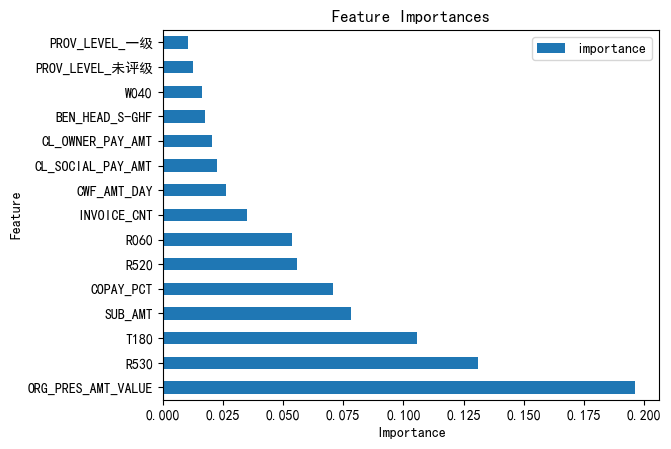

In [71]:
plot_importance(model, X_train)

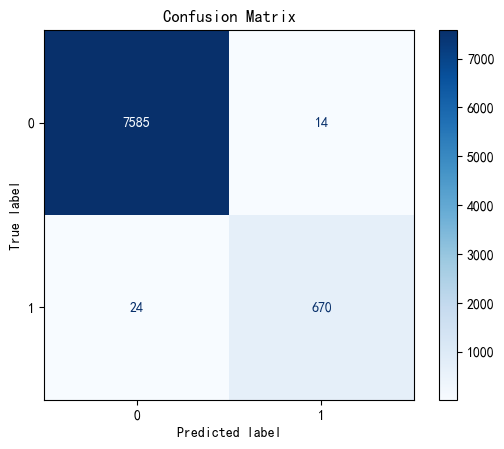

In [118]:
# 画出混淆矩阵
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
# 预测
y_pred = model.predict(X_test)
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


In [66]:
XGBC_misc = find_misclassified_samples(X_test, y_test, y_pred)
print("Misclassified samples:")
print(XGBC_misc[0:5].T)

Misclassified samples:
                           9123      802        144       6769      26045
COPAY_PCT               7.000000  7.000000  12.000000  7.000000  7.000000
CWF_AMT_DAY             1.000000  1.000000   1.000000  1.000000  1.000000
INVOICE_CNT             2.000000  1.000000   1.000000  2.000000  1.000000
POLICY_CNT              1.000000  1.000000   1.000000  1.000000  1.000000
ORG_PRES_AMT_VALUE      1.255297  2.000004   2.000004  1.477136  1.602071
SUB_AMT                 1.477136  2.000004   2.000004  1.477136  1.602071
CL_SOCIAL_PAY_AMT       1.079217 -3.000000  -3.000000 -3.000000 -3.000000
CL_THIRD_PARTY_PAY_AMT -3.000000 -3.000000  -3.000000 -3.000000 -3.000000
CL_OWNER_PAY_AMT       -3.000000 -3.000000  -3.000000 -3.000000 -3.000000
CL_SELF_CAT_PAY_AMT    -3.000000 -3.000000  -3.000000 -3.000000 -3.000000
T190                    0.000000  0.000000   0.000000  0.000000  0.000000
R540                    0.000000  0.000000   0.000000  0.000000  0.000000
R100           

In [11]:
# xgboost
import xgboost as xgb
from xgboost import XGBClassifier

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
model = XGBClassifier()
kfold = StratifiedKFold(n_splits=10)
results = cross_val_score(model, X_train, y_train, cv=kfold)
print("Accuracy: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

Accuracy: 99.46% (0.11%)


In [40]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
#Need to research
#research_one: n_epoch
#research_one: max_depth
param_test1 = {
    'n_estimators': [10,20,30,40,50,100,120,140,200],
    'min_child_weight': [1, 2, 3, 4, 5,6,7],
    'max_depth':[3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,30,40,50],
    }

xgb_res = RandomizedSearchCV(estimator = XGBClassifier(), 
                       param_distributions=param_test1,
                       n_iter=100)

xgb_res.fit(X_train, y_train)

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=100,
                   param_distributions={'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15, 16,
                                                      17, 18, 19, 20, 30, 40,
                                                      50],
                                        'min_child_weight': [1, 2, 3, 4, 5, 6,
                                                             7],
                                        'n_estimators': [10, 20, 30, 40, 50,
                                                         100, 120, 140, 200]})

In [41]:
print('max_depth_min_child_weight')
# print('gsearch1.grid_scores_', xgb_res.cv_results_)
print('gsearch1.best_params_', xgb_res.best_params_)
print('gsearch1.best_score_', xgb_res.best_score_)

max_depth_min_child_weight
gsearch1.best_params_ {'n_estimators': 120, 'min_child_weight': 1, 'max_depth': 14}
gsearch1.best_score_ 0.9945132914657859


In [17]:

# 创建XGBoost模型
model = XGBClassifier(n_estimators=120, max_depth=14, min_child_weight=1)
# 训练模型
model.fit(X_train, y_train)
# 预测测试集
y_pred = model.predict(X_test)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))


Confusion Matrix:
[[13089    40]
 [   36  2418]]
Classification Report:
              precision    recall  f1-score   support

           0   0.997257  0.996953  0.997105     13129
           1   0.983727  0.985330  0.984528      2454

    accuracy                       0.995123     15583
   macro avg   0.990492  0.991142  0.990816     15583
weighted avg   0.995126  0.995123  0.995125     15583



In [18]:
import pickle
pickle.dump(model, open("xgbc_model.pkl", "wb"))

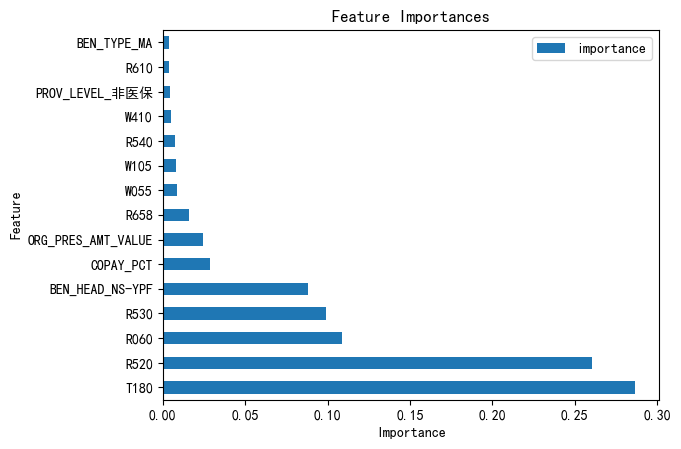

In [73]:
plot_importance(model, X_train)

In [13]:
# MLP
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization


In [19]:
model = Sequential()
model.add(Dense(256, input_shape=(309,)))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=128))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=64))
model.add(LeakyReLU(negative_slope=0.05))
model.add(BatchNormalization())
model.add(Dropout(rate=0.5))
model.add(Dense(units=1,activation='sigmoid'))


c:\Users\12132\Desktop\Project_hemeow\pyvenv\TFvenv\Lib\site-packages\keras\src\layers\core\dense.py:86: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │        79,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,393 (482.00 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 1,408 (5.50 KB)

In [14]:
model.compile(loss='binary_crossentropy', 
              optimizer='adam', metrics=['accuracy'])

In [122]:
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=100, 
                         batch_size=100,verbose=2)

Epoch 1/100
266/266 - 2s - 7ms/step - accuracy: 0.7897 - loss: 0.5049 - val_accuracy: 0.9466 - val_loss: 0.1783
Epoch 2/100
266/266 - 0s - 2ms/step - accuracy: 0.9534 - loss: 0.1663 - val_accuracy: 0.9857 - val_loss: 0.0500
Epoch 3/100
266/266 - 0s - 2ms/step - accuracy: 0.9740 - loss: 0.0892 - val_accuracy: 0.9879 - val_loss: 0.0412
Epoch 4/100
266/266 - 0s - 2ms/step - accuracy: 0.9785 - loss: 0.0722 - val_accuracy: 0.9879 - val_loss: 0.0390
Epoch 5/100
266/266 - 0s - 2ms/step - accuracy: 0.9821 - loss: 0.0623 - val_accuracy: 0.9891 - val_loss: 0.0313
Epoch 6/100
266/266 - 0s - 2ms/step - accuracy: 0.9844 - loss: 0.0545 - val_accuracy: 0.9898 - val_loss: 0.0263
Epoch 7/100
266/266 - 0s - 2ms/step - accuracy: 0.9858 - loss: 0.0490 - val_accuracy: 0.9917 - val_loss: 0.0257
Epoch 8/100
266/266 - 0s - 2ms/step - accuracy: 0.9858 - loss: 0.0456 - val_accuracy: 0.9907 - val_loss: 0.0261
Epoch 9/100
266/266 - 0s - 2ms/step - accuracy: 0.9872 - loss: 0.0418 - val_accuracy: 0.9920 - val_loss:

In [24]:
import matplotlib.pyplot as plt

def visu_train_history(train_history,train_metric,validation_metric):
    plt.plot(train_history.history[train_metric])
    plt.plot(train_history.history[validation_metric])
    plt.title('Train History')
    plt.ylabel(train_metric)
    plt.xlabel('Epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

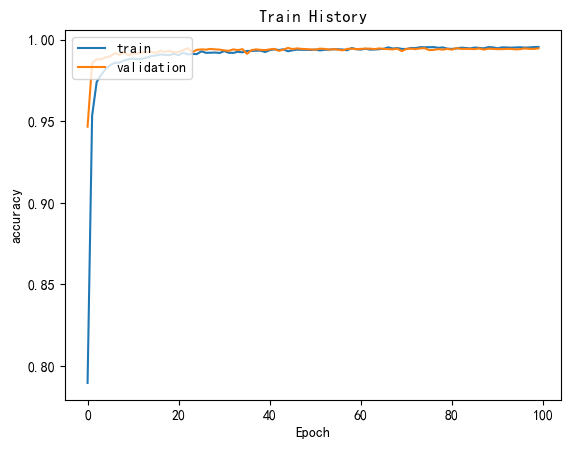

In [124]:
visu_train_history(train_history,'accuracy','val_accuracy')

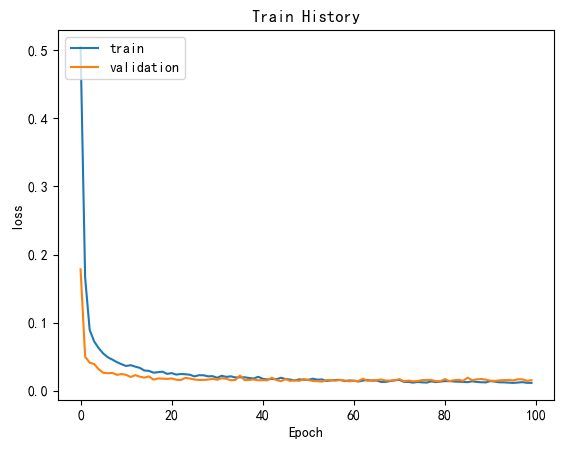

In [125]:
visu_train_history(train_history,'loss','val_loss')

In [126]:
evaluate_result = model.evaluate(x=X_test, 
                        y=y_test)

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step - accuracy: 0.9946 - loss: 0.0223


In [127]:
evaluate_result

[0.021100103855133057, 0.9946942925453186]

In [128]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 886us/step
Confusion Matrix:
[[7579   20]
 [  24  670]]
Classification Report:
              precision    recall  f1-score   support

           0   0.996843  0.997368  0.997106      7599
           1   0.971014  0.965418  0.968208       694

    accuracy                       0.994694      8293
   macro avg   0.983929  0.981393  0.982657      8293
weighted avg   0.994682  0.994694  0.994687      8293



In [17]:
model.compile(loss='binary_crossentropy', 
              optimizer='adagrad', metrics=['accuracy'])

In [19]:
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=100, 
                         batch_size=100,verbose=2)

Epoch 1/100
266/266 - 2s - 6ms/step - accuracy: 0.5447 - loss: 0.9145 - val_accuracy: 0.9063 - val_loss: 0.4422
Epoch 2/100
266/266 - 0s - 2ms/step - accuracy: 0.5962 - loss: 0.8005 - val_accuracy: 0.9019 - val_loss: 0.4198
Epoch 3/100
266/266 - 0s - 2ms/step - accuracy: 0.6305 - loss: 0.7423 - val_accuracy: 0.9041 - val_loss: 0.4028
Epoch 4/100
266/266 - 0s - 2ms/step - accuracy: 0.6568 - loss: 0.6998 - val_accuracy: 0.9075 - val_loss: 0.3920
Epoch 5/100
266/266 - 0s - 2ms/step - accuracy: 0.6664 - loss: 0.6812 - val_accuracy: 0.9115 - val_loss: 0.3764
Epoch 6/100
266/266 - 0s - 2ms/step - accuracy: 0.6901 - loss: 0.6424 - val_accuracy: 0.9148 - val_loss: 0.3682
Epoch 7/100
266/266 - 0s - 2ms/step - accuracy: 0.7037 - loss: 0.6251 - val_accuracy: 0.9171 - val_loss: 0.3596
Epoch 8/100
266/266 - 0s - 2ms/step - accuracy: 0.7143 - loss: 0.6060 - val_accuracy: 0.9191 - val_loss: 0.3489
Epoch 9/100
266/266 - 0s - 2ms/step - accuracy: 0.7243 - loss: 0.5918 - val_accuracy: 0.9221 - val_loss:

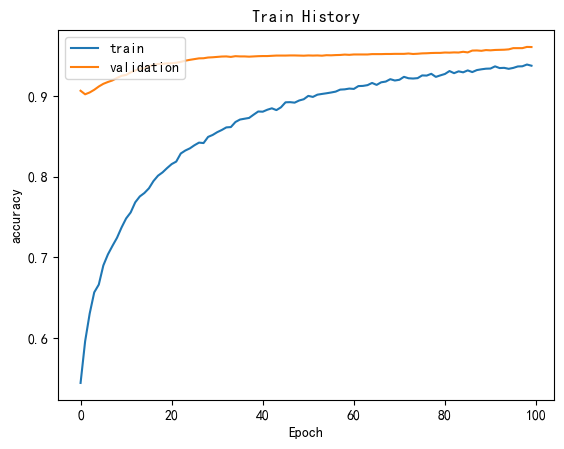

In [20]:
visu_train_history(train_history,'accuracy','val_accuracy')

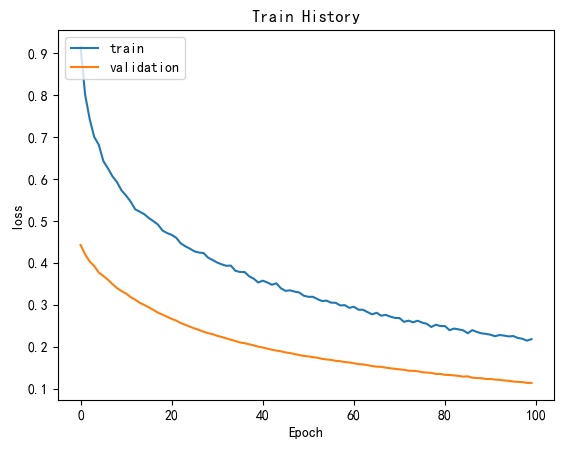

In [21]:
visu_train_history(train_history,'loss','val_loss')

In [22]:
evaluate_result = model.evaluate(x=X_test, 
                        y=y_test)

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step - accuracy: 0.9615 - loss: 0.1040


In [23]:
evaluate_result

[0.10615082830190659, 0.9615338444709778]

In [24]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step
Confusion Matrix:
[[7598    1]
 [ 318  376]]
Classification Report:
              precision    recall  f1-score   support

           0   0.959828  0.999868  0.979439      7599
           1   0.997347  0.541787  0.702148       694

    accuracy                       0.961534      8293
   macro avg   0.978588  0.770828  0.840793      8293
weighted avg   0.962968  0.961534  0.956234      8293



In [25]:
model.compile(loss='binary_crossentropy', 
              optimizer='adamax', metrics=['accuracy'])

In [26]:
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=100, 
                         batch_size=100,verbose=2)

Epoch 1/100
266/266 - 2s - 7ms/step - accuracy: 0.9506 - loss: 0.1710 - val_accuracy: 0.9690 - val_loss: 0.0856
Epoch 2/100
266/266 - 0s - 2ms/step - accuracy: 0.9587 - loss: 0.1387 - val_accuracy: 0.9783 - val_loss: 0.0695
Epoch 3/100
266/266 - 0s - 2ms/step - accuracy: 0.9624 - loss: 0.1233 - val_accuracy: 0.9836 - val_loss: 0.0561
Epoch 4/100
266/266 - 0s - 2ms/step - accuracy: 0.9660 - loss: 0.1143 - val_accuracy: 0.9837 - val_loss: 0.0546
Epoch 5/100
266/266 - 0s - 2ms/step - accuracy: 0.9692 - loss: 0.1025 - val_accuracy: 0.9848 - val_loss: 0.0495
Epoch 6/100
266/266 - 0s - 2ms/step - accuracy: 0.9704 - loss: 0.0975 - val_accuracy: 0.9858 - val_loss: 0.0458
Epoch 7/100
266/266 - 0s - 2ms/step - accuracy: 0.9735 - loss: 0.0854 - val_accuracy: 0.9864 - val_loss: 0.0434
Epoch 8/100
266/266 - 0s - 2ms/step - accuracy: 0.9763 - loss: 0.0820 - val_accuracy: 0.9860 - val_loss: 0.0432
Epoch 9/100
266/266 - 0s - 2ms/step - accuracy: 0.9752 - loss: 0.0802 - val_accuracy: 0.9866 - val_loss:

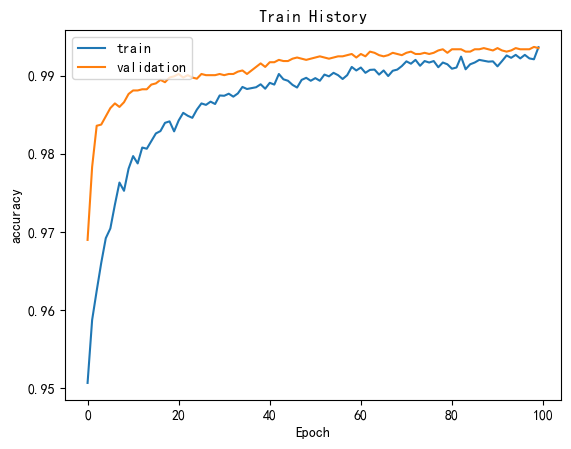

In [27]:
visu_train_history(train_history,'accuracy','val_accuracy')

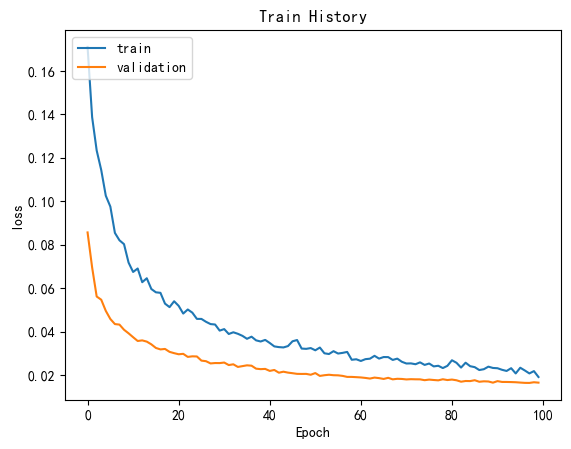

In [28]:
visu_train_history(train_history,'loss','val_loss')

In [29]:
evaluate_result = model.evaluate(x=X_test, 
                        y=y_test)

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.9952 - loss: 0.0150


In [30]:
evaluate_result

[0.015761343762278557, 0.9946942925453186]

In [31]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step
Confusion Matrix:
[[7587   12]
 [  32  662]]
Classification Report:
              precision    recall  f1-score   support

           0   0.995800  0.998421  0.997109      7599
           1   0.982196  0.953890  0.967836       694

    accuracy                       0.994694      8293
   macro avg   0.988998  0.976156  0.982472      8293
weighted avg   0.994662  0.994694  0.994659      8293



In [21]:
model.compile(loss='binary_crossentropy', 
              optimizer='nadam', metrics=['accuracy'])

In [22]:
train_history =model.fit(x=X_train, 
                         y=y_train, 
                         validation_split=0.2, 
                         epochs=200, 
                         batch_size=100,verbose=2)

Epoch 1/200
499/499 - 4s - 8ms/step - accuracy: 0.8435 - loss: 0.3843 - val_accuracy: 0.9774 - val_loss: 0.0766
Epoch 2/200
499/499 - 1s - 3ms/step - accuracy: 0.9709 - loss: 0.1015 - val_accuracy: 0.9872 - val_loss: 0.0468
Epoch 3/200
499/499 - 1s - 3ms/step - accuracy: 0.9804 - loss: 0.0686 - val_accuracy: 0.9900 - val_loss: 0.0329
Epoch 4/200
499/499 - 1s - 3ms/step - accuracy: 0.9829 - loss: 0.0584 - val_accuracy: 0.9920 - val_loss: 0.0279
Epoch 5/200
499/499 - 1s - 3ms/step - accuracy: 0.9861 - loss: 0.0480 - val_accuracy: 0.9924 - val_loss: 0.0259
Epoch 6/200
499/499 - 1s - 3ms/step - accuracy: 0.9859 - loss: 0.0443 - val_accuracy: 0.9925 - val_loss: 0.0246
Epoch 7/200
499/499 - 1s - 3ms/step - accuracy: 0.9876 - loss: 0.0407 - val_accuracy: 0.9932 - val_loss: 0.0232
Epoch 8/200
499/499 - 1s - 3ms/step - accuracy: 0.9888 - loss: 0.0363 - val_accuracy: 0.9937 - val_loss: 0.0212
Epoch 9/200
499/499 - 1s - 3ms/step - accuracy: 0.9884 - loss: 0.0361 - val_accuracy: 0.9930 - val_loss:

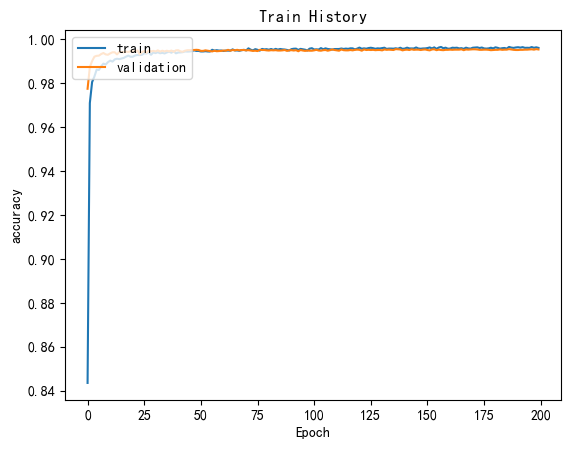

In [25]:
visu_train_history(train_history,'accuracy','val_accuracy')

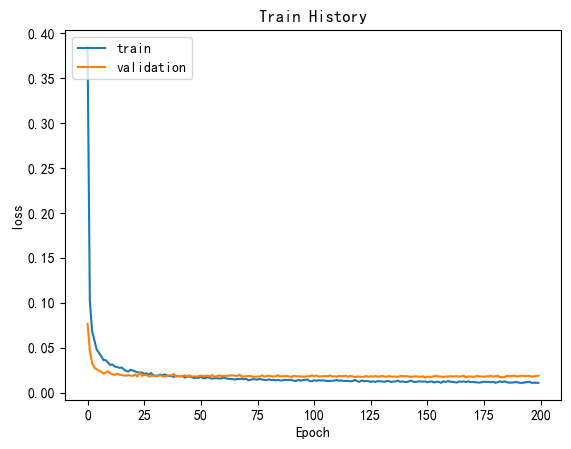

In [26]:
visu_train_history(train_history,'loss','val_loss')

In [27]:
evaluate_result = model.evaluate(x=X_test, 
                        y=y_test)

487/487 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - accuracy: 0.9959 - loss: 0.0154


In [28]:
evaluate_result

[0.01596635952591896, 0.9960213303565979]

In [29]:
y_pred = model.predict(X_test)
y_pred=[y_pred>=0.5]
y_pred=y_pred[0].astype(int)
# 评估模型
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred,digits=6))

487/487 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step
Confusion Matrix:
[[13104    25]
 [   37  2417]]
Classification Report:
              precision    recall  f1-score   support

           0   0.997184  0.998096  0.997640     13129
           1   0.989762  0.984923  0.987337      2454

    accuracy                       0.996021     15583
   macro avg   0.993473  0.991509  0.992488     15583
weighted avg   0.996016  0.996021  0.996017     15583



In [30]:
model.save('mlp_model.keras')